In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pickle

rfm = pd.read_csv('../data/processed/customer_segments.csv')

print("Rows:", rfm.shape[0])
print("Columns:", rfm.columns.tolist())

Rows: 5878
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment', 'Cluster', 'Cluster_Name', 'PCA1', 'PCA2']


In [2]:
# A customer who has NOT purchased in last 90 days = churned
# Our reference date is the same as before
reference_date = pd.to_datetime('2011-12-10')

# Churn label: 1 = churned, 0 = active
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print("Churned customers:", rfm['Churned'].sum())
print("Active customers: ", (rfm['Churned'] == 0).sum())
print("\nChurn Rate: {:.1f}%".format(rfm['Churned'].mean() * 100))

Churned customers: 2989
Active customers:  2889

Churn Rate: 50.9%


In [12]:
# Remove Recency and R_Score — they directly define churn (data leakage)
feature_cols = ['Frequency', 'Monetary', 'F_Score', 'M_Score']

X = rfm[feature_cols].astype(float)
y = rfm['Churned']

print("Features shape:", X.shape)
print("Churn breakdown:\n", y.value_counts())

Features shape: (5878, 4)
Churn breakdown:
 Churned
1    2989
0    2889
Name: count, dtype: int64


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {1: 2989, 0: 2889}
After SMOTE:  {1: 2989, 0: 2989}


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))

Training rows: 4782
Testing rows:  1196


In [15]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, lr_pred))

===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       588
           1       0.69      0.70      0.69       608

    accuracy                           0.69      1196
   macro avg       0.69      0.69      0.69      1196
weighted avg       0.69      0.69      0.69      1196



In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("===== RANDOM FOREST =====")
print(classification_report(y_test, rf_pred))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       588
           1       0.64      0.64      0.64       608

    accuracy                           0.63      1196
   macro avg       0.63      0.63      0.63      1196
weighted avg       0.63      0.63      0.63      1196



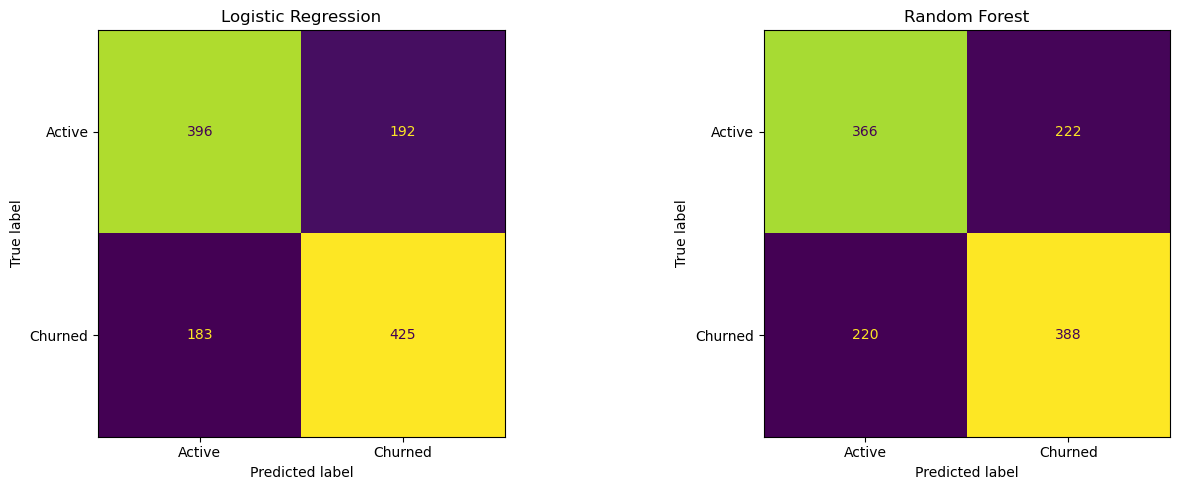

✅ Saved to outputs/chart_confusion_matrix.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred),
    display_labels=['Active', 'Churned']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

# Random Forest
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred),
    display_labels=['Active', 'Churned']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig('../outputs/chart_confusion_matrix.png')
plt.show()
print("✅ Saved to outputs/chart_confusion_matrix.png")

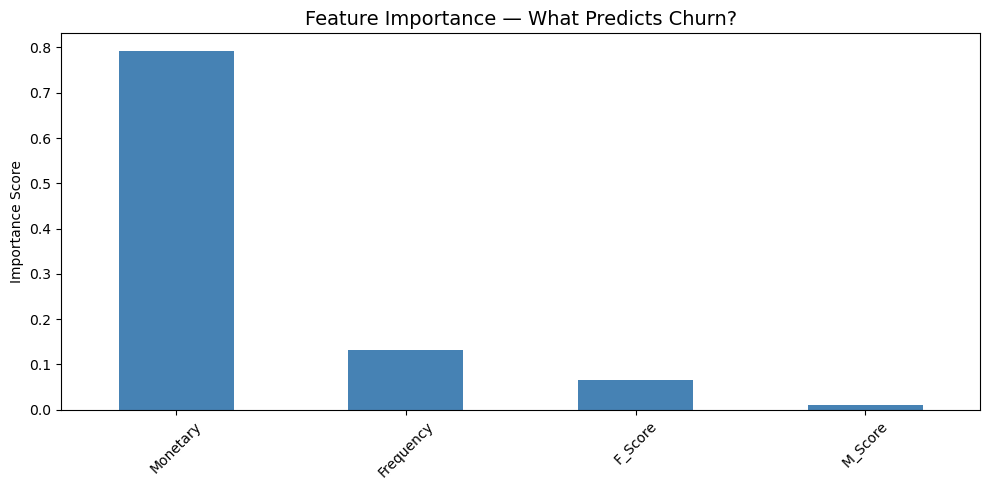

✅ Saved to outputs/chart_churn_importance.png


In [19]:
importance = pd.Series(rf.feature_importances_,
    index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — What Predicts Churn?', fontsize=14)
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart_churn_importance.png')
plt.show()
print("✅ Saved to outputs/chart_churn_importance.png")

In [20]:
# Use original unscaled data for predictions
X_original = scaler.transform(rfm[feature_cols].astype(float))
rfm['Churn_Probability'] = rf.predict_proba(X_original)[:, 1]
rfm['Churn_Risk'] = pd.cut(rfm['Churn_Probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High'])

top_50_atrisk = rfm[rfm['Churned'] == 0].sort_values(
    'Churn_Probability', ascending=False).head(50)

print("===== TOP 10 ACTIVE CUSTOMERS MOST LIKELY TO CHURN =====")
print(top_50_atrisk[['Customer ID', 'Recency', 'Frequency',
    'Monetary', 'Churn_Probability', 'Churn_Risk']].head(10).to_string())

===== TOP 10 ACTIVE CUSTOMERS MOST LIKELY TO CHURN =====
      Customer ID  Recency  Frequency  Monetary  Churn_Probability Churn_Risk
5028      17427.0       72          1    100.80                1.0       High
2787      15163.0       18          2    304.47                1.0       High
240       12587.0        8          1    144.00                1.0       High
4789      17186.0       47          2    144.00                1.0       High
4589      16982.0       61          1    384.06                1.0       High
4205      16594.0       75          1    181.09                1.0       High
3161      15539.0        7          1    538.46                1.0       High
5005      17403.0       36          2    400.57                1.0       High
994       13349.0       11          1    247.32                1.0       High
1650      14015.0       53          1    917.34                1.0       High


In [22]:
# Save Logistic Regression (winner) instead of Random Forest
with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/churn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Fix churn probability using lr
X_original = scaler.transform(rfm[feature_cols].astype(float))
rfm['Churn_Probability'] = lr.predict_proba(X_original)[:, 1]
rfm['Churn_Risk'] = pd.cut(rfm['Churn_Probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High'])

rfm.to_csv('../data/processed/churn_scores.csv', index=False)

print("✅ Logistic Regression model saved to models/churn_model.pkl")
print("✅ Scaler saved to models/churn_scaler.pkl")
print("✅ Churn scores saved to data/processed/churn_scores.csv")

✅ Logistic Regression model saved to models/churn_model.pkl
✅ Scaler saved to models/churn_scaler.pkl
✅ Churn scores saved to data/processed/churn_scores.csv
